In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39907 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:39907/status,
Dashboard: http://127.0.0.1:39907/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33323,Workers: 0
Dashboard: http://127.0.0.1:39907/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38709,Total threads: 6
Dashboard: http://127.0.0.1:42023/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:44319,


In [4]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [5]:
from utils import *

In [6]:
data = dict(dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

In [7]:
ISOBLJ = ISOBLJ_Struct(input_data,data=data)

In [8]:
# ISOBLJ.data
ISOBLJ.open_datasets(prefix=['scalars'])

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [9]:
THETA = ISOBLJ.get_variable("THETA")
SALT = ISOBLJ.get_variable("SALT")
RHOAnoma = ISOBLJ.get_variable("RHOAnoma")

In [10]:
def find_coord(var,coord):
    for vcoord in var[0].coords:
        if coord in vcoord:
            return vcoord

In [11]:
# dx = var[0][find_coord(var,"dx")][0,0].values

In [12]:
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from plot_utils import *

In [13]:
# real_hfac = Uvel.UVEL_c0m_Td2_s089p_dz8.hFacW_c0m_Td2_s089p_dz8
# print(real_hfac.shape)
# print(hfacc.shape)

In [14]:
# real_hfac = THETA.THETA_c60m_Td2_vshift24_dz4.hFacC_c60m_Td2_vshift24_dz4.transpose(...,"Z_dz4").values
# dz = 8

# hfacc_surf, hfacc_depth = construct_hfacc_surfaces(real_hfac,dz)

# # plt.plot(hfacc_depth[0,:])

# vert_top = get_faces(hfacc_surf/abs(dz),z_shift=0,flip=False)
# vert_bottom = get_faces(hfacc_depth/abs(dz),z_shift=65,flip=True)

# # print(vert_top["Y"])
# # print(vert_bottom["Y"])

# ax = plt.axes(projection='3d',computed_zorder=False)

# plot_hfacc_surf_3D(vert_top,vert_bottom,ax=ax)

# plt.show()

In [15]:
# hfacc_depth

In [17]:
# vert_bottom["X"],vert_top["X"]
# restoring_x = vert_bottom["X"][0][1:-2,2] + 76
# restoring_y = vert_bottom["Y"][0][1:-2,2] + 76
# restoring_x, restoring_y = np.meshgrid(restoring_x, restoring_y)

In [19]:
# plt.plot(restoring_x)

## Plot different channel depths

In [20]:
# np.sort(Uvel.data_vars)
import re

def tryint(s):
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    """ Turn a string into a list of string and number chunks.
        "z23a" -> ["z", 23, "a"]
    """
    return [ tryint(c) for c in re.split('([0-9]+)', s) ]

def sort_nicely(l):
    """ Sort the given list in the way that humans expect.
    """
    l.sort(key=alphanum_key)

var_names = list(THETA.data_vars)
sort_nicely(var_names)

In [21]:
var_names = ["THETA_c0m_Td2_vshift48_dz2",
             "THETA_c80m_Td2_vshift48_dz2", 
             "THETA_c160m_Td2_vshift48_dz2"]

var_units=r"Temperature [$^\circ\,\mathrm{C}$]"

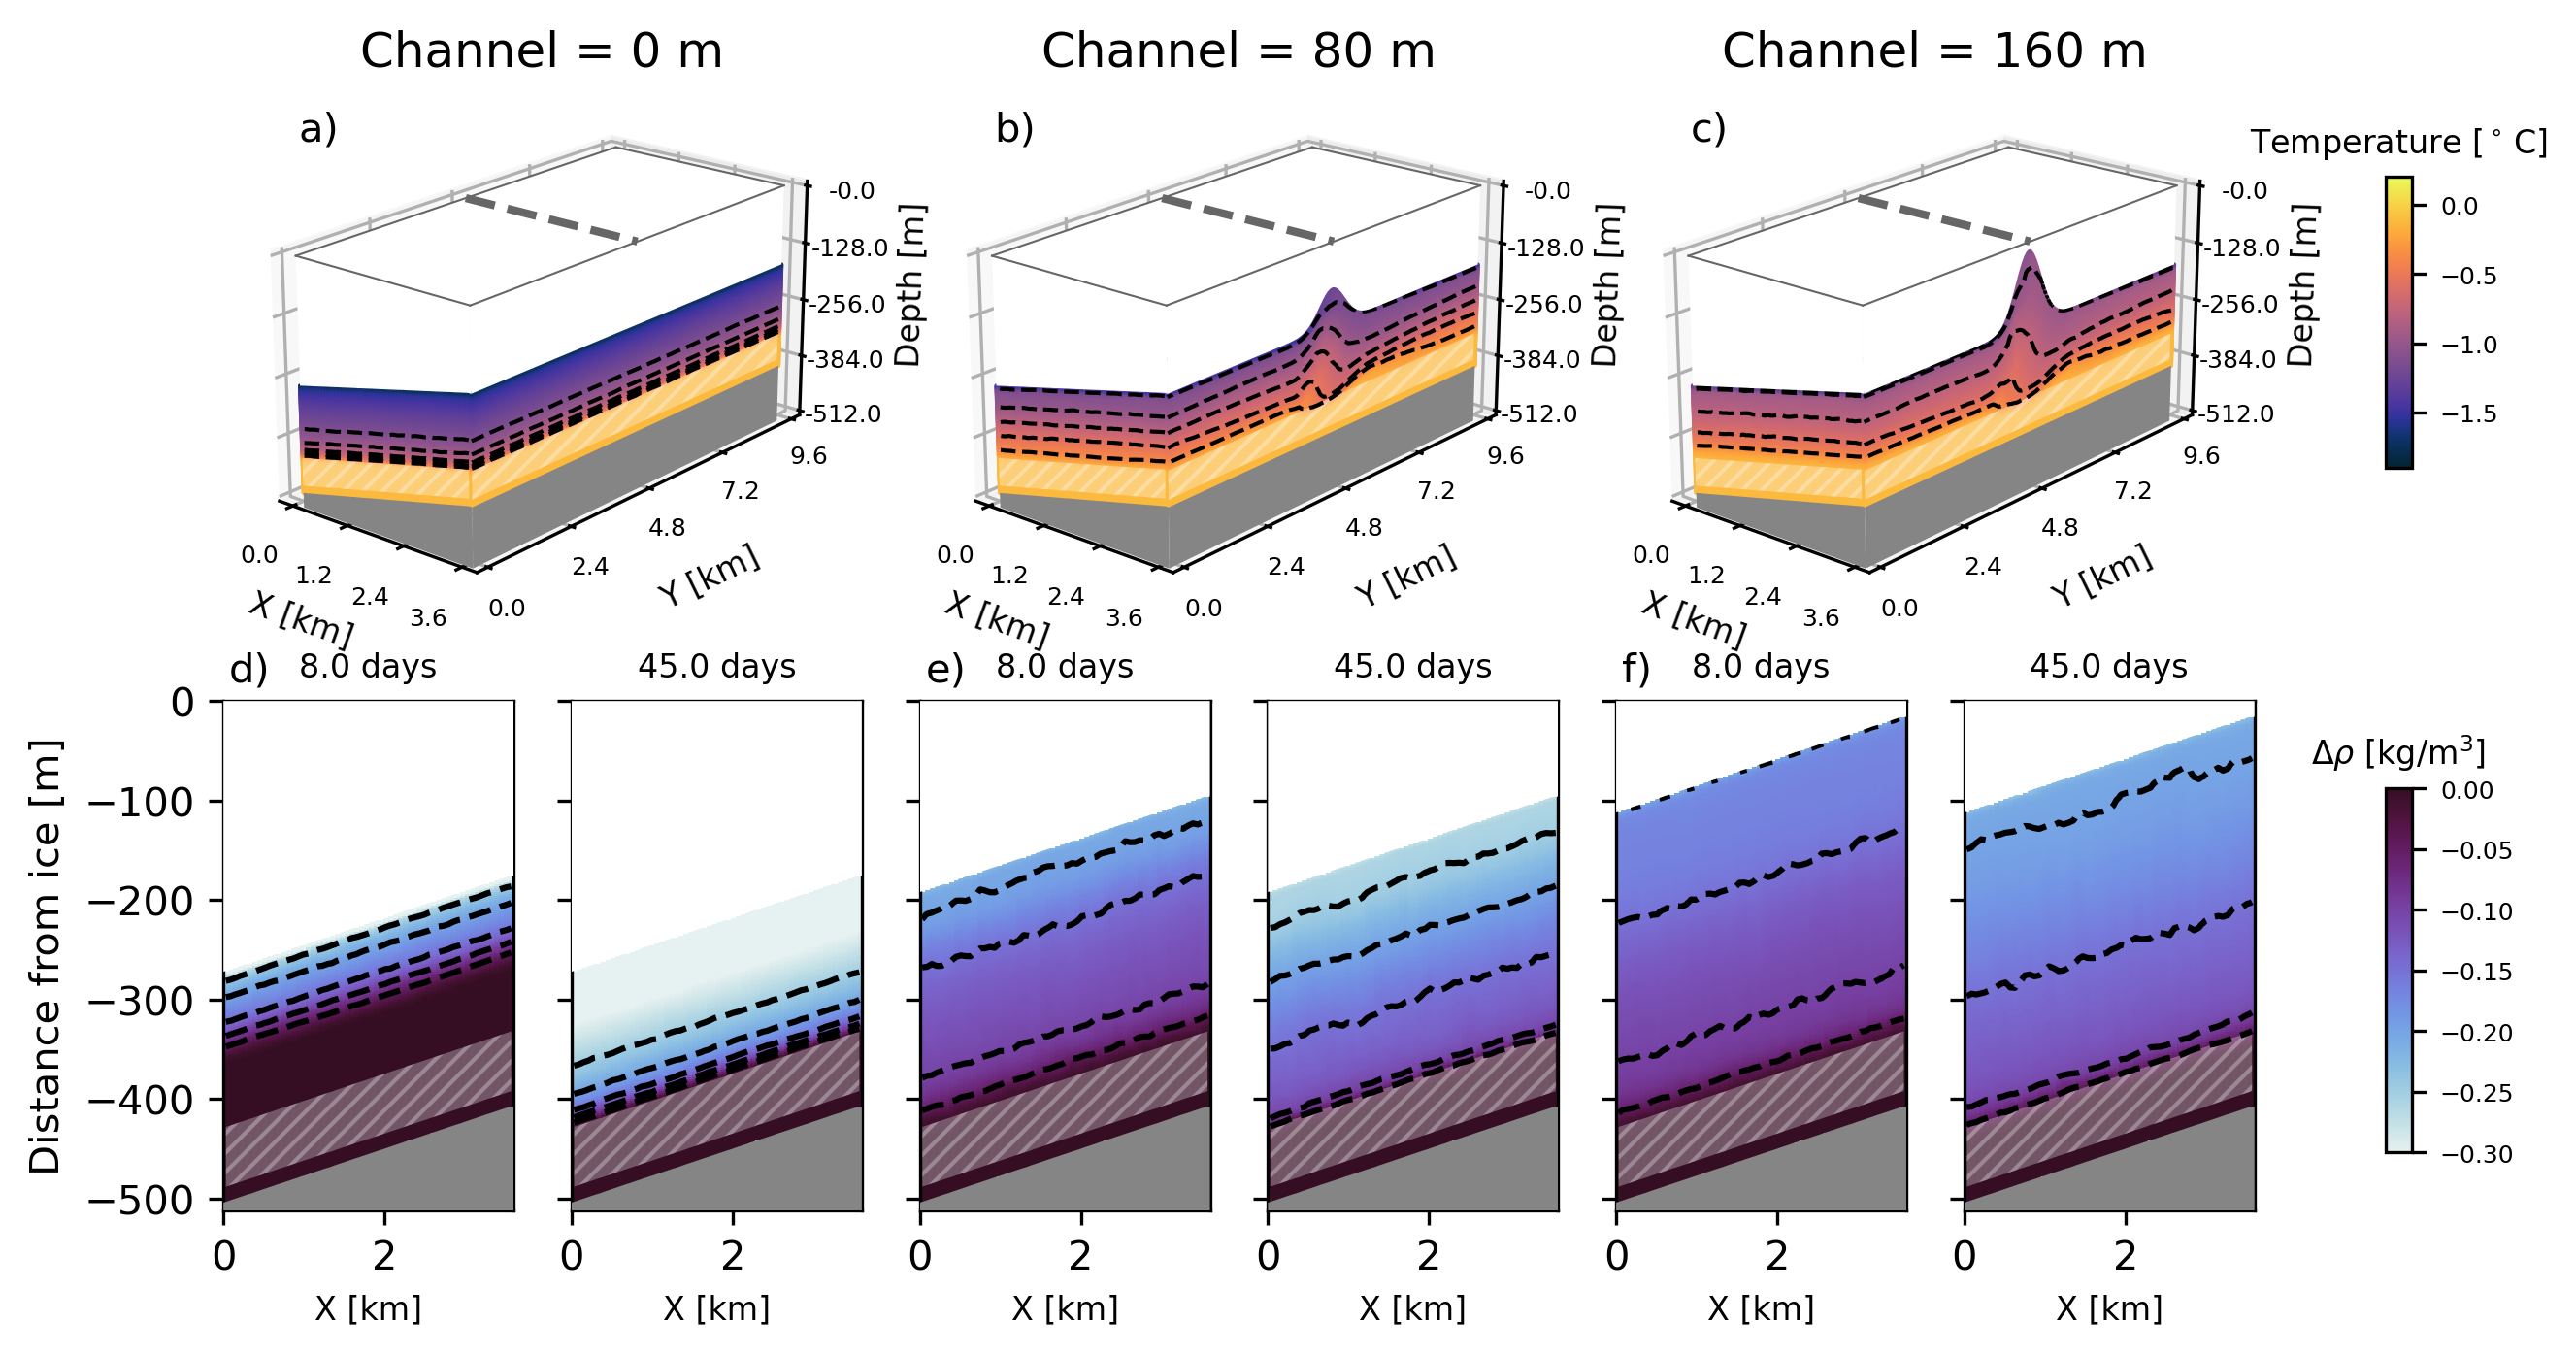

In [22]:
fig = plt.figure(figsize=(9, 5),dpi=300)

time=-1

gs = GridSpec(2, 6, figure=fig)

ax1 = fig.add_subplot(gs[0, 0:2], projection='3d',computed_zorder=False)
ax2 = fig.add_subplot(gs[0, 2:4], projection='3d',computed_zorder=False)
ax3 = fig.add_subplot(gs[0, 4:], projection='3d',computed_zorder=False)

ax = [ax1,ax2,ax3]

#### Bottom Panels
ax1b = fig.add_subplot(gs[1:, 0])
ax2b = fig.add_subplot(gs[1:, 1])
ax3b = fig.add_subplot(gs[1:, 2])
ax4b = fig.add_subplot(gs[1:, 3])
ax5b = fig.add_subplot(gs[1:, 4])
ax6b = fig.add_subplot(gs[1:, 5])
axs = [ax1b, ax2b, ax3b, ax4b, ax5b, ax6b]

counter=0
counterb=0
for var in var_names:
    if "Td2" in var and "vshift48" in var and "dz2" in var:
        coor = [ coor for coor in  THETA[var].coords if "Z" in coor]
        variable = THETA[var].transpose(...,coor[0])
        
        dx = variable[find_coord(variable,"dx")][0,0].values/1000
        dy = variable[find_coord(variable,"dy")][0,0].values/1000
        dz = -variable[find_coord(variable,"dr")][0].values
    
        kw = {
            'vmin': -1.9,
            'vmax': 0.2,
            'cmap': cm.cm.thermal,
            'zorder':-1
        }
        hfacc_var = [coord for coord in THETA[var].coords if "hFac" in coord]
        hfacc = variable[var.replace(var.split("_")[0],
                                     hfacc_var[0].split("_")[0])]
        
        var2plot = (variable.isel(time=time))
        var2plot = var2plot.where(var2plot!=0).values

        density=RHOAnoma[var.replace("THETA","RHOAnoma")].transpose(...,coor[0])
        density=density.where(~np.isnan(var2plot))
        
        plot_3d_cube_contours(ax[counter], density.isel(time=time),
                              levels=np.arange(-0.25,-0,0.05),
                              colors='k',linewidths=1)
        
        cbar = plot_imshow3D(ax[counter],var2plot,dgrid=(dx,dy,dz),kw=kw)

        ax[counter].plot([0, 60], [80, 80], 0, linestyle='--',
                         linewidth=2,color='0.4', zorder=1e3)
        
        hfacc_shape = hfacc.shape[-1]
        hfacc_surf, hfacc_depth = construct_hfacc_surfaces(hfacc.values,abs(dz))
        # Divide by dz to match the number of pixels of imshow.
        vert_top = get_faces(hfacc_surf/abs(dz),z_shift=0,delta_expand=0)
        vert_bottom = get_faces(hfacc_depth/abs(dz),z_shift=67*4,
                                flip=True,delta_expand=0)
        plot_hfacc_surf_3D(vert_top,vert_bottom,ax=ax[counter])

        restoring_x = vert_bottom["X"][0][1:-2,2]
        restoring_y = vert_bottom["Y"][0][1:-2,2]
        # ax[counter].plot(np.arange(0,len(restoring_x)),np.zeros_like(restoring_x), restoring_x - 16/2, color='white',linestyle="-.")
        # ax[counter].plot(np.zeros_like(restoring_y) + 60, np.arange(0,len(restoring_y)), restoring_y - 16/2, color='white',linestyle="-.")
        # ax[counter].plot(np.arange(0,len(restoring_x)),np.zeros_like(restoring_x), restoring_x - 76/2, color='white',linestyle="--")
        # ax[counter].plot(np.zeros_like(restoring_y) + 60, np.arange(0,len(restoring_y)), restoring_y - 76/2, color='white',linestyle="--")
        ax[counter].fill_between(np.arange(0,len(restoring_x)),np.zeros_like(restoring_x), restoring_x - 16/2, 
                                 np.arange(0,len(restoring_x)),np.zeros_like(restoring_x), restoring_x - 76/2,
                                hatch="/////", color="white",alpha=0.3, linewidth=0.0)
        ax[counter].fill_between(np.zeros_like(restoring_y) + 60, np.arange(0,len(restoring_y)), restoring_y - 16/2, 
                                 np.zeros_like(restoring_y) + 60, np.arange(0,len(restoring_y)), restoring_y - 76/2,
                                hatch="/////", color="white",alpha=0.3, linewidth=0.0)
        

        ax[counter].set_title("Channel = {0} m".format(var.split("_c")[1].split("m_")[0]))
        counter+=1

        vert_top = get_faces(hfacc_surf/abs(dz),z_shift=0,delta_expand=0,X=80)
        vert_bottom = get_faces(hfacc_depth/abs(dz),z_shift=67*4,
                                flip=True,delta_expand=0,X=80)
        
        restoring_x = vert_bottom["X"][0][1:-2,2]*2
        restoring_y = vert_bottom["Y"][0][1:-2,2]*2
        
        plot_hfacc_surf_2D(vert_top,vert_bottom,ax=axs[counterb],
                           key="X",grid=np.array((60/1000,60/1000,-2)))
        rho_snapshot = density.isel(time=31)
        rho_snapshot.isel(YC=80).plot(y="Z_dz2", ax=axs[counterb],
                                               vmin=-0.3,vmax=0,
                                               cmap=cm.cm.dense,
                                               add_colorbar=False)
        rho_snapshot.isel(YC=80).plot.contour(y="Z_dz2", ax=axs[counterb],
                                                 levels=np.arange(-0.25,-0,0.05),
                                                 colors='k',
                                                 add_colorbar=False)

        axs[counterb].set_title("{0} days".format(rho_snapshot.time.values/24),
                                fontsize=8)
        
        # axs[counterb].plot(rho_snapshot.XC, -restoring_x+16, color='white',linestyle="-.")
        # axs[counterb].plot(rho_snapshot.XC, -restoring_x+76, color='white',linestyle="--")
        axs[counterb].fill_between(rho_snapshot.XC, -restoring_x+16, -restoring_x+76,
                                  hatch="/////", color="white",alpha=0.3, linewidth=0.0)
        counterb+=1

        plot_hfacc_surf_2D(vert_top,vert_bottom,ax=axs[counterb],
                           key="X",grid=np.array((60/1000,60/1000,-2)))
        rho_snapshot = density.isel(time=time)
        cbar1 = rho_snapshot.isel(YC=80).plot(y="Z_dz2", ax=axs[counterb],
                                                 vmin=-0.3,vmax=0,
                                                 cmap=cm.cm.dense,
                                                 add_colorbar=False)
        rho_snapshot.isel(YC=80).plot.contour(y="Z_dz2", ax=axs[counterb],
                                                 levels=np.arange(-0.25,-0,0.05),
                                                 colors='k',
                                                 add_colorbar=False)
        axs[counterb].set_title("{0} days".format(rho_snapshot.time.values/24),
                                fontsize=8)
        
        # axs[counterb].plot(rho_snapshot.XC, -restoring_x+16, color='white',linestyle="-.")
        # axs[counterb].plot(rho_snapshot.XC, -restoring_x+76, color='white',linestyle="--")
        axs[counterb].fill_between(rho_snapshot.XC, -restoring_x+16, -restoring_x+76,
                                  hatch="/////", color="white",alpha=0.3,linewidth=0.0)
        counterb+=1
        
[a.invert_zaxis() for a in ax]

[a.set_box_aspect((1,2,1),zoom=1.2) for a in ax] 

[a.set_xlabel("X [km]", fontsize=8, labelpad=-8) for a in ax] 
[a.set_ylabel("Y [km] \n \n \n", fontsize=8, labelpad=-8) for a in ax] 

[a.set_zlabel("Depth [m]", fontsize=8, labelpad=-6) for a in ax] 
[a.tick_params(axis="x", pad=-2) for a in ax] 
[a.tick_params(axis="y", pad=-2) for a in ax] 
[a.tick_params(axis="z", pad=-2) for a in ax] 

for a in ax:
    a.yaxis.labelpad=8
    a.yaxis.set_tick_params(labelsize=6)
    a.xaxis.set_tick_params(labelsize=6)
    a.zaxis.set_tick_params(labelsize=6)
    
ax1b.set_ylabel("Distance from ice [m]")

# [ a.set_ylim(0,400) for a in axs ] 
[ a.set_ylabel("") for a in axs[1:] ] 
[ a.yaxis.set_ticklabels([]) for a in axs[1:] ] 
[a.set_xlabel("X [km]", fontsize=8) for a in axs] 


ax1.text2D(0.02, 0.9, "a)", fontsize=10, transform=ax1.transAxes)
ax2.text2D(0.02, 0.9, "b)", fontsize=10, transform=ax2.transAxes)
ax3.text2D(0.02, 0.9, "c)", fontsize=10, transform=ax3.transAxes)

ax1b.text(0.02, 1.04, "d)", fontsize=10, transform=ax1b.transAxes)
ax3b.text(0.02, 1.04, "e)", fontsize=10, transform=ax3b.transAxes)
ax5b.text(0.02, 1.04, "f)", fontsize=10, transform=ax5b.transAxes)

cbar_ax = fig.add_axes([0.95, 0.62, 0.01, 0.2])
fig.colorbar(cbar, cax =cbar_ax)
cbar_ax.set_title(var_units,fontsize=8)
cbar_ax.yaxis.set_tick_params(labelsize=6)

cbar_ax1 = fig.add_axes([0.95, 0.15, 0.01, 0.25])
fig.colorbar(cbar1, cax =cbar_ax1)
cbar_ax1.set_title(r"$\Delta \rho$ [$\mathrm{kg/m}^3$]",fontsize=8)
cbar_ax1.yaxis.set_tick_params(labelsize=6)

plt.savefig("./figures/Fig_3_temp_density.png", bbox_inches='tight')